In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm



In [2]:
train_path = "../input/osic-pulmonary-fibrosis-progression/train.csv"
test_path = "../input/osic-pulmonary-fibrosis-progression/test.csv"
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print("Training data shape: ", train_df.shape)



Training data shape:  (1394, 7)


In [3]:
train_df["Patient_Week"] = (
    train_df["Patient"].astype(str) + "_" + train_df["Weeks"].astype(str)
)
output = pd.DataFrame()
gb = tqdm(train_df.groupby("Patient"), total=train_df["Patient"].nunique())
for _, usr_df in gb:
    usr_output = pd.DataFrame()
    for week, tmp in usr_df.groupby("Weeks"):
        rename_cols = {
            "Weeks": "base_Week",
            "FVC": "base_FVC",
            "Percent": "base_Percent",
            "Age": "base_Age",
        }
        tmp = tmp.drop(columns="Patient_Week").rename(columns=rename_cols)
        drop_cols = []  # previously ["Percent"]
        _usr_output = (
            usr_df.drop(columns=drop_cols)
            .rename(columns={"Weeks": "predict_Week"})
            .merge(tmp, on="Patient")
        )
        _usr_output["Week_passed"] = (
            _usr_output["predict_Week"] - _usr_output["base_Week"]
        )
        usr_output = pd.concat([usr_output, _usr_output], ignore_index=True)
    output = pd.concat([output, usr_output], ignore_index=True)

train_df = output[output["Week_passed"] != 0].reset_index(drop=True)
print("Processed train shape:", train_df.shape)



100%|██████████| 158/158 [00:03<00:00, 51.35it/s]

Processed train shape: (10952, 15)


In [4]:
dup_cols = [c for c in train_df.columns if c.endswith("_x")]
for dup in dup_cols:
    base = dup[:-2]
    dup_y = base + "_y"
    if dup_y in train_df.columns:
        train_df.drop(columns=[dup], inplace=True)
        train_df.rename(columns={dup_y: base}, inplace=True)



In [5]:
train_df = pd.get_dummies(train_df, columns=["Sex"])
train_df = pd.get_dummies(train_df, columns=["SmokingStatus"])
train_df = train_df.rename(
    columns={
        "Sex_Female": "Female",
        "Sex_Male": "Male",
        "SmokingStatus_Currently smokes": "CurrentlySmokes",
        "SmokingStatus_Ex-smoker": "ExSmoker",
        "SmokingStatus_Never smoked": "NeverSmoked",
    }
)



In [6]:
X = train_df.drop(
    ["Patient", "FVC", "base_Week", "predict_Week", "Patient_Week"], axis=1
)
y = train_df["FVC"]



In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)
print(f"training data: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"validation data: {X_val.shape[0]} rows, {X_val.shape[1]} features")



training data: 8761 rows, 11 features
validation data: 2191 rows, 11 features


In [8]:
from xgboost import XGBRegressor

regr_XGB_opt = XGBRegressor(
    base_score=0.5,
    booster="gbtree",
    colsample_bytree=0.9,
    eta=0.01,
    gamma=0,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=1,
    n_estimators=1000,
    n_jobs=-1,
    random_state=0,
    subsample=0.8,
    tree_method="exact",
    verbosity=0,
)



In [9]:
regr_XGB_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False,
)



/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.01, eval_metric=None,
             feature_types=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [10]:
y_pred_val = regr_XGB_opt.predict(X_val)



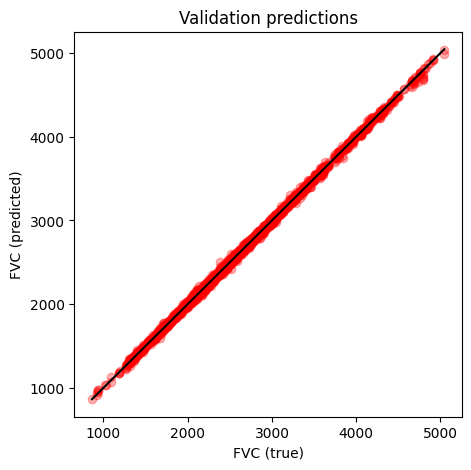

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_val, y_pred_val, color="r", alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="k")
plt.xlabel("FVC (true)")
plt.ylabel("FVC (predicted)")
plt.title("Validation predictions")
plt.show()



In [12]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"Validation RMSE: {rmse:.4f}")




Validation RMSE: 20.6609


In [13]:
# ---------- Laplace metric and validation‑based calibration ----------
def laplace_metric(y_true, y_pred, sigma):
    sigma_clipped = np.maximum(sigma, 70)
    delta = np.minimum(np.abs(y_true - y_pred), 1000)
    return np.mean(
        -np.sqrt(2) * delta / sigma_clipped - np.log(np.sqrt(2) * sigma_clipped)
    )


# Linear calibration on validation set (y = a * pred + b)
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression().fit(y_pred_val.reshape(-1, 1), y_val)
a_calib, b_calib = lin_reg.coef_[0], lin_reg.intercept_
print(f"Linear calibration factors – a: {a_calib:.5f}, b: {b_calib:.2f}")

# Candidates for sigma (confidence)
sigma_candidates = [70, 100, 120, 150, max(70, int(np.round(rmse * np.sqrt(2))))]

best_score = -np.inf
best_sigma = 70

# Evaluate only sigma (calibrated predictions already include bias)
for s in sigma_candidates:
    metric_val = laplace_metric(y_val, a_calib * y_pred_val + b_calib, s)
    if metric_val > best_score:
        best_score = metric_val
        best_sigma = s

print(f"Chosen sigma (confidence) after calibration: {best_sigma}")

# Prepare test features (same preprocessing as training)
sample_sub_path = "../input/osic-pulmonary-fibrosis-progression/sample_submission.csv"
submission_template = pd.read_csv(sample_sub_path)

test_base = test_df.rename(
    columns={
        "Weeks": "base_Week",
        "FVC": "base_FVC",
        "Percent": "base_Percent",
        "Age": "base_Age",
    }
)

submission = submission_template.copy()
submission["Patient"] = submission["Patient_Week"].apply(lambda x: x.split("_")[0])
submission["predict_Week"] = submission["Patient_Week"].apply(
    lambda x: int(x.split("_")[1])
)

test_merged = submission.drop(columns=["FVC", "Confidence"]).merge(
    test_base, on="Patient"
)
test_merged["Week_passed"] = test_merged["predict_Week"] - test_merged["base_Week"]

test_merged = pd.get_dummies(test_merged, columns=["Sex"])
test_merged = pd.get_dummies(test_merged, columns=["SmokingStatus"])
test_merged = test_merged.rename(
    columns={
        "Sex_Female": "Female",
        "Sex_Male": "Male",
        "SmokingStatus_Currently smokes": "CurrentlySmokes",
        "SmokingStatus_Ex-smoker": "ExSmoker",
        "SmokingStatus_Never smoked": "NeverSmoked",
    }
)

# Remove duplicate columns if any
dup_cols_test = [c for c in test_merged.columns if c.endswith("_x")]
for dup in dup_cols_test:
    base = dup[:-2]
    dup_y = base + "_y"
    if dup_y in test_merged.columns:
        test_merged.drop(columns=[dup], inplace=True)
        test_merged.rename(columns={dup_y: base}, inplace=True)

X_test_sub = test_merged.drop(
    [
        "Patient",
        "Patient_Week",
        "predict_Week",
        "base_Week",
    ],
    axis=1,
)

# Align columns with training set, filling missing numeric columns with median
missing_cols = set(X.columns) - set(X_test_sub.columns)
for col in missing_cols:
    if np.issubdtype(train_df[col].dtype, np.number):
        X_test_sub[col] = train_df[col].median()
    else:
        X_test_sub[col] = 0
X_test_sub = X_test_sub[X.columns]

# Predict and apply linear calibration
FVC_pred_sub = regr_XGB_opt.predict(X_test_sub)
FVC_pred_sub = a_calib * FVC_pred_sub + b_calib
FVC_pred_sub = np.clip(FVC_pred_sub, 0, 5000)



Linear calibration factors – a: 1.00252, b: -6.83
Chosen sigma (confidence) after calibration: 70


In [14]:
submission_final = submission_template.copy()
submission_final["FVC"] = FVC_pred_sub
submission_final["Confidence"] = best_sigma
submission_final.to_csv("submission.csv", index=False)
print("Submission file written to submission.csv with shape:", submission_final.shape)

Submission file written to submission.csv with shape: (1908, 3)
